# 최종 미션 — 파이썬 재현 노트북
파일명을 `미션재현_이름.ipynb`로 바꾸고 시작하세요.

## 이 노트북의 사용법 ⚠️ 중요

**코드는 여러분이 직접 씁니다.** 주석으로 "무엇을 해야 하는지"만 안내되어 있습니다.

```python
# [해야 할 일] 결측이 몇 개인지 확인
# [힌트] 표의 정보를 요약해주는 메서드 (교재 2-3장)
# [결과] 어떤 컬럼에 몇 개인지 보여야 함

여기에 코드 작성  ← 이 자리를 채우는 게 여러분의 일
```

### ⚠️ 미션은 스스로 수행합니다

**코드 작성과 분석 판단은 질문 대상이 아닙니다.** 오늘은 심사가 진행되는 날이며, 이 부분이 평가 대상입니다.

| 구분 | 질문 가능 여부 |
|---|---|
| 미션 요구사항·제출 형식이 이해되지 않을 때 | ✅ 질문 가능 |
| 데이터 컬럼의 의미가 이해되지 않을 때 | ✅ 질문 가능 |
| 실행 환경 오류 (파일 업로드, Colab 접속 등) | ✅ 질문 가능 |
| **코드를 어떻게 쓰는지** | ❌ 스스로 해결 |
| **어떤 그래프를 골라야 하는지** | ❌ 스스로 판단 |
| **기준값을 얼마로 정해야 하는지** | ❌ 스스로 판단 |
| **문법 오류·에러 해결** | ❌ 스스로 해결 |

**막혔을 때 찾아볼 자료** (전부 배포되어 있습니다)

| 상황 | 참조 |
|---|---|
| Orange3로는 했는데 코드를 모르겠다 | 교재 **4-9 로제타석** (Orange3 ↔ 파이썬 대응표) |
| 문법이 기억 안 난다 | 교재 **2장** (pandas 4동작) / 어제 실습 노트북 |
| 위젯 조작이 기억 안 난다 | Orange3 매뉴얼 **STEP 1~16** |
| 분석 흐름이 막막하다 | 어제 저녁 관찰 노트북 **Q1~Q6** |

> 💡 **한 번에 완성하려 하지 마세요.** 한 줄 쓰고 실행 → 결과 보고 → 다음 줄. 에러는 정상이며, 에러를 읽고 고치는 것도 평가 대상입니다.

### 📚 출처 메모 (NASA 저장소에서 확인한 내용을 여기에)
```
어떤 실험인가:
제공 기관:
Citation:
원본 형식 → 배포 형식:
```

---
## 준비 — 데이터 불러오기
> 이 셀만 완성되어 있습니다. 나머지는 직접 작성하세요.
> 시작 전: 왼쪽 📁 패널에 `battery_M.csv`와 `battery_NASA.csv`를 모두 드래그 업로드!

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# 파일명 뒤에 _260722 추가
m = pd.read_csv("/content/battery_M_260722.csv")          # PART 1 · 스냅샷
nasa = pd.read_csv("/content/battery_NASA_260722.csv")    # PART 2 · 시계열

print("M   :", m.shape, "  한 행 = 셀 하나")
print("NASA:", nasa.shape, "  한 행 = 셀 하나의 한 사이클")

M   : (30, 9)   한 행 = 셀 하나
NASA: (636, 11)   한 행 = 셀 하나의 한 사이클


---
# PART 1 — M데이터 (스냅샷)
## 필수 재현 ① · 데이터 확인
> Orange3의 **Column Statistics**로 본 것을 코드로 다시 확인합니다.

In [3]:
# ─────────────────────────────────────────────
# [해야 할 일] 데이터의 앞부분을 눈으로 확인
# [힌트] 표의 첫 몇 줄만 보여주는 메서드
# ─────────────────────────────────────────────


In [13]:
# ─────────────────────────────────────────────
# [해야 할 일] 각 컬럼의 타입과 결측(Non-Null) 개수 확인
# [힌트] "출석부 훑기" — 교재 2-3장의 세 버튼 중 두 번째
# [결과] 어떤 컬럼에 결측이 몇 개인지 알 수 있어야 함
# ─────────────────────────────────────────────
m.info()


# ✏️ 확인한 내용 (발표 3·4장 재료):
#    결측 컬럼: current_capacity              개수: 3


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   cell_id              30 non-null     object 
 1   cycle_count          30 non-null     int64  
 2   initial_capacity     30 non-null     float64
 3   current_capacity     27 non-null     float64
 4   soh                  30 non-null     float64
 5   internal_resistance  30 non-null     float64
 6   avg_temp             30 non-null     float64
 7   charge_time          30 non-null     int64  
 8   batch_no             30 non-null     int64  
dtypes: float64(5), int64(3), object(1)
memory usage: 2.2+ KB


In [9]:
# ─────────────────────────────────────────────
# [해야 할 일] 수치 컬럼의 요약 통계로 이상한 값 찾기
# [힌트] 세 버튼 중 세 번째. min/max를 유심히 볼 것
# [결과] 물리적으로 불가능한 값이 눈에 띄어야 함
# ─────────────────────────────────────────────
m.describe()

# ✏️ 이상치: 컬럼  soh           값   121
# 왜 불가능한가: MAX 100인데 SOH는100을 초과했기때문


,cycle_count,initial_capacity,current_capacity,soh,internal_resistance,avg_temp,charge_time,batch_no
count,30.000000,30.000000,27.000000,30.000000,30.000000,30.000000,30.000000,30.000000
mean,555.266667,2797.073333,2587.214815,93.160000,33.113333,30.850000,100.066667,2.133333
std,221.722867,23.290947,148.545827,7.603747,5.818682,3.680494,10.891102,0.860366
min,152.000000,2751.700000,2266.400000,80.600000,24.000000,23.500000,75.000000,1.000000
25%,372.250000,2782.975000,2478.800000,88.125000,28.550000,28.300000,92.250000,1.000000
50%,593.500000,2798.800000,2592.900000,93.000000,32.250000,31.400000,100.000000,2.000000
75%,716.000000,2808.325000,2712.800000,97.900000,38.550000,33.200000,109.000000,3.000000
max,886.000000,2856.200000,2777.800000,121.000000,42.900000,36.300000,123.000000,3.000000


In [16]:
# ─────────────────────────────────────────────
# [해야 할 일] 이상치를 제외한 데이터를 m_clean 이라는 이름으로 만들기
# [힌트] 조건을 걸어 골라내기 = 마스킹 (교재 1-5, 2-5장)
#        SOH는 100%를 넘을 수 없다
# [결과] print로 제거 전/후 행 수를 비교해 보세요
# ─────────────────────────────────────────────
m_clean = m[m['soh'] <= 100]

print("제거 전:", len(m))
print("제거 후:", len(m_clean))


제거 전: 30
제거 후: 29


## 필수 재현 ② · 최종 판정
> Orange3의 **Select Rows**로 한 선별을 코드로 재현합니다. **두 결과가 같아야 정상입니다.**

In [18]:
# ─────────────────────────────────────────────
# [해야 할 일] 내가 Orange3에서 정한 기준을 조건으로 옮겨 최종 셀 선별
# [힌트] 조건이 2개 이상이면 각각 괄호로 감싸고 & 로 연결
#        df[(조건1) & (조건2)]  ← 괄호 빠뜨리면 에러 (오늘의 1등 에러)
# [결과] 선별된 셀 수를 출력하고, cell_id와 soh를 확인
# ─────────────────────────────────────────────
final = m_clean[m_clean['soh'] >= 80]

print("선별된 셀 수:", len(final))
final[['cell_id', 'soh']]


선별된 셀 수: 29


,cell_id,soh
0,M01,92.0
1,M02,85.5
2,M03,93.5
3,M04,80.6
4,M05,99.0
5,M06,87.3
6,M07,98.2
7,M08,99.0
8,M09,96.4
9,M10,83.1


In [20]:
# ─────────────────────────────────────────────
# [해야 할 일] Orange3 결과와 일치하는지 대조
# ─────────────────────────────────────────────
# ✏️ Orange3 Select Rows의 Data Out 셀 수:      29개
# ✏️ 파이썬 len(final):                         29개
# ✏️ 일치? 예
#    → 아니오라면: 부등호 방향(>= vs >), 기준값, 조건 개수를 하나씩 대조해 보세요
print("파이썬 len(final):", len(final))

파이썬 len(final): 29


---
# 관문 ① · 기준 민감도 ★변별
### "그 기준, 흔들리면 결과가 얼마나 달라지나요?"

기준값 하나로 판정하고 끝내면 평범합니다. **기준이 얼마나 예민한지 수치로** 보여주세요.

In [22]:
# ─────────────────────────────────────────────
# [해야 할 일] 내 기준값을 -3 / 그대로 / +3 으로 바꿔가며
#              각각 몇 개가 통과하는지 표처럼 출력
#
# [생각해볼 것] 같은 코드를 값만 바꿔 3번 쓰는 것보다,
#               값 목록을 만들어 반복시키는 게 낫지 않을까?
#               (어제 배운 for문 — 리스트를 하나씩 꺼내 쓰기)
#
# [결과 예시]
#   soh >= 82: 통과 26개 / 탈락 3개
#   soh >= 85: 통과 24개 / 탈락 5개
#   soh >= 88: 통과 22개 / 탈락 7개
# ─────────────────────────────────────────────
base_threshold = 83
thresholds = [base_threshold - 3, base_threshold, base_threshold + 3]

for th in thresholds:
    passed = len(m_clean[m_clean['soh'] >= th])
    failed = len(m_clean) - passed
    print(f"soh >= {th}: 통과 {passed}개 / 탈락 {failed}개")

# ✏️ 발표 7장 문장: "기준을 3%p 낮추면 1개가 더 통과합니다.
#                    그만큼 예민한 경계이므로 Orange3 EDA를 근거로 83로 정했습니다"


soh >= 80: 통과 29개 / 탈락 0개
soh >= 83: 통과 28개 / 탈락 1개
soh >= 86: 통과 23개 / 탈락 6개


In [ ]:
# ─────────────────────────────────────────────
# [해야 할 일 · 심화] 내 기준 경계에 아슬아슬하게 걸린 셀 찾기
# [힌트] 기준값 ±2 범위에 있는 셀만 골라내면 됩니다 (조건 2개)
# [왜?] "이 셀은 왜 탈락시켰나요?" 질문에 사례로 답할 수 있습니다
# ─────────────────────────────────────────────



---
# 관문 ② · 결측의 영향 ★변별
### "빈칸을 채운 게 답을 바꾸지 않았나요?"

결측을 평균으로 채우고 넘어가면 놓치는 게 있습니다.

In [23]:
# ─────────────────────────────────────────────
# [해야 할 일 1] 결측이 있던 셀들이 어떤 값을 가졌는지 확인
# [힌트] 결측 여부를 판단하는 메서드가 있습니다 (NaN인가?)
#        그 결과를 마스킹 조건으로 쓰면 결측 행만 골라집니다
# [보고 싶은 것] 그 셀들의 cell_id, soh, internal_resistance
# ─────────────────────────────────────────────
missing_cells = m_clean[m_clean['current_capacity'].isna()]

missing_cells[['cell_id', 'soh', 'internal_resistance']]

# ✏️ 결측 셀들의 SOH는 합격 경계 근처인가, 확실한 불합격인가?
결축 셀들의 SOH는 모두 80% 이상이므로 합격 범위 내에 있는 정상 셀들입니다.

,cell_id,soh,internal_resistance
5,M06,87.3,42.8
17,M18,85.1,41.5
26,M27,94.4,35.9


In [24]:
# ─────────────────────────────────────────────
# [해야 할 일 2] 결측을 두 가지 방식으로 처리하고 최종 판정을 비교
#   ⓐ 평균으로 채우기  → 내 기준 적용 → 몇 개 통과?
#   ⓑ 해당 행 제외하기 → 내 기준 적용 → 몇 개 통과?
#
# [힌트] 빈칸 채우기 / 빈칸 있는 행 버리기에 해당하는 메서드가 각각 있습니다
#        (교재 4-9 로제타석의 '결측 채우기' 행 참고)
# [결과] 두 방식의 최종 셀 수를 나란히 출력
# ─────────────────────────────────────────────

# ⓐ 평균으로 채우기 (fillna 사용)
m_fill = m_clean.copy()
m_fill['current_capacity'] = m_fill['current_capacity'].fillna(m_fill['current_capacity'].mean())
passed_a = len(m_fill[m_fill['soh'] >= 83])

# ⓑ 해당 행 버리기 (dropna 사용)
m_drop = m_clean.dropna(subset=['current_capacity'])
passed_b = len(m_drop[m_drop['soh'] >= 83])

print(f"ⓐ 평균으로 채우기 적용 후 통과: {passed_a}개")
print(f"ⓑ 결측 행 제외하기 적용 후 통과: {passed_b}개")

# ✏️ 판정이 달라졌는가? 나는 어느 쪽을 택했고 왜인가:
결측치 컬럼은 판정 기준 정상 셀 3개가 탈락했습니다. 따라서 결측을 처리하여 유지하는 a 방식을 선택했습니다.

ⓐ 평균으로 채우기 적용 후 통과: 28개
ⓑ 결측 행 제외하기 적용 후 통과: 25개


---
# 관문 ③ · 함정 회피 ★변별
### "상관 1위가 정말 원인인가요?"

이 데이터에는 **의도적으로 심어둔 함정**이 있습니다. 순위표만 보면 걸립니다.

In [25]:
# ─────────────────────────────────────────────
# [해야 할 일] 이상치를 "제거하기 전(m)"과 "제거한 후(m_clean)"의
#              SOH 상관 순위를 각각 구해서 비교
#
# [힌트] 상관은 corr() — 단, cell_id는 글자라 계산에서 빼야 합니다
#        특정 열을 빼는 방법: drop(columns=[...])
#        SOH 기준 순위만 보려면 결과에서 'soh' 열을 뽑고 정렬
# [결과] 두 순위표를 나란히 출력해 어떤 변수의 순위가 크게 움직였는지 확인
# ─────────────────────────────────────────────

#제거 전
corr_before = m.drop(columns=['cell_id']).corr()['soh'].sort_values(ascending=False)
#제거 후
corr_after = m_clean.drop(columns=['cell_id']).corr()['soh'].sort_values(ascending=False)

print("--- [제거 전 SOH 상관계수] ---")
print(corr_before)
print("\n--- [제거 후 SOH 상관계수] ---")
print(corr_after)

--- [제거 전 SOH 상관계수] ---
soh                    1.000000
current_capacity       0.679110
batch_no               0.411979
initial_capacity       0.027397
cycle_count           -0.210082
avg_temp              -0.216368
charge_time           -0.259754
internal_resistance   -0.446378
Name: soh, dtype: float64

--- [제거 후 SOH 상관계수] ---
soh                    1.000000
current_capacity       0.991175
batch_no               0.598602
cycle_count           -0.325065
avg_temp              -0.336624
initial_capacity      -0.341384
charge_time           -0.391908
internal_resistance   -0.842087
Name: soh, dtype: float64


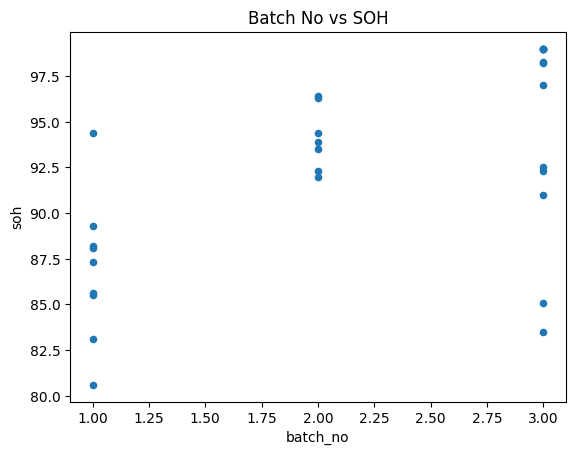

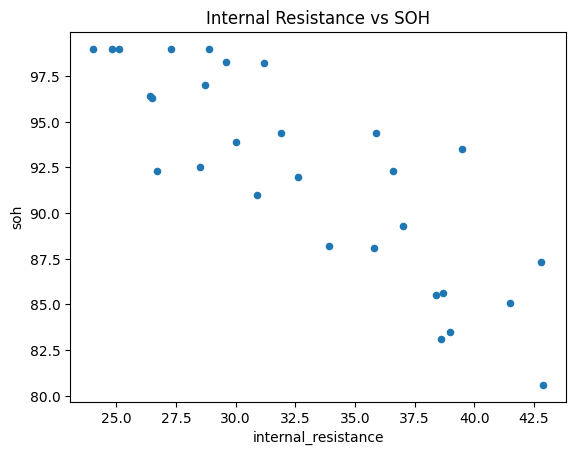

In [26]:
# ─────────────────────────────────────────────
# [해야 할 일] 의심스러운 변수를 산점도로 다시 확인
# [힌트] 산점도는 plot.scatter(x=..., y=...)
# [따져볼 것] 이 변수가 배터리를 늙게 할 "물리적 이유"가 있는가?
#             (예: 생산 배치 번호가 커지면 배터리가 빨리 늙는다? 말이 되는가?)
# ─────────────────────────────────────────────

m_clean.plot.scatter(x='batch_no', y='soh', title='Batch No vs SOH')
plt.show()

m_clean.plot.scatter(x='internal_resistance', y='soh', title='Internal Resistance vs SOH')
plt.show()

# ✏️ 상관 1위 변수: internal_resistance             물리적으로 타당한가? 예
# ✏️ 함정으로 의심되는 변수:batch_no
#배제 이유:이상치 제거 전에는 단순 수치 배치 번호가 상관이 높아 보였으나, 생산 순서나 배치 번호 자체가 배터리 노화의 물리적 원인이 될 수 없기 때문


---
# PART 2 — NASA 데이터 (시계열)
## 2단계 · 데이터 확인

In [27]:
# ─────────────────────────────────────────────
# [해야 할 일] NASA 데이터의 구조 파악 — 앞부분 + 결측 확인
# [주목] 결측이 있다면 어느 컬럼에, 몇 개나?
# ─────────────────────────────────────────────

print("--- [데이터 상위 5개 행] ---")
display(nasa.head())

print("\n--- [컬럼 정보 및 결측치 확인] ---")
nasa.info()


--- [데이터 상위 5개 행] ---


,cell_id,cycle_count,ambient_temp,capacity,soh,internal_resistance,avg_temp,max_temp,discharge_time,min_voltage,is_eol
0,B0005,1,24,1.8565,92.8,NaN,32.6,39.0,61.5,2.612,0
1,B0005,2,24,1.8463,92.3,NaN,32.7,39.0,61.2,2.587,0
2,B0005,3,24,1.8353,91.8,NaN,32.6,38.8,60.9,2.652,0
3,B0005,4,24,1.8353,91.8,NaN,32.5,38.8,60.5,2.593,0
4,B0005,5,24,1.8346,91.7,NaN,32.4,38.7,60.5,2.547,0



--- [컬럼 정보 및 결측치 확인] ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 636 entries, 0 to 635
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   cell_id              636 non-null    object 
 1   cycle_count          636 non-null    int64  
 2   ambient_temp         636 non-null    int64  
 3   capacity             636 non-null    float64
 4   soh                  636 non-null    float64
 5   internal_resistance  579 non-null    float64
 6   avg_temp             636 non-null    float64
 7   max_temp             636 non-null    float64
 8   discharge_time       636 non-null    float64
 9   min_voltage          636 non-null    float64
 10  is_eol               636 non-null    int64  
dtypes: float64(7), int64(3), object(1)
memory usage: 54.8+ KB


In [29]:
# ─────────────────────────────────────────────
# [해야 할 일 1] 셀마다 사이클 수가 다른지 확인
# [힌트] 셀별로 묶어서(groupby) 각 그룹의 최대 사이클을 보면 됩니다
# [왜?] 셀마다 관측 길이가 다르면 비교할 때 주의해야 합니다 (발표 '한계' 재료)
# ─────────────────────────────────────────────

cycle_counts = nasa.groupby('cell_id')['cycle_count'].max()
print("--- [셀별 최대 사이클 수] ---")
print(cycle_counts)

# ─────────────────────────────────────────────
# [해야 할 일 2 · 관문② 심화] 결측이 어디에 있는지 확인 ★
# [힌트] 결측인 행만 골라낸 뒤, 셀별·사이클별로 어디에 몰려 있는지 보세요
#        (groupby로 묶어 min/max 사이클을 보면 구간이 드러납니다)
# [따져볼 것] 결측이 무작위인가, 특정 구간에 몰려 있는가?
#             몰려 있다면 평균으로 채우는 게 왜 위험한가?
# ─────────────────────────────────────────────

nasa_missing = nasa[nasa.isna().any(axis=1)]

print("\n--- [결측치가 존재하는 사이클 구간] ---")
print(nasa_missing.groupby('cell_id')['cycle_count'].agg(['min', 'max', 'count']))

# ✏️ 결측 구간: internal_resistance 컬럼의 결측은 초반 구간
# 평균 대체가 위험한 이유:초반 정상 작동 구간의 측정값을 전체 평균으로 대체하게 되면
  중후반부의 실제 열화 경향성을 제대로 반영하지 못하고 데이터 분포가 왜곡되기 때문


--- [셀별 최대 사이클 수] ---
cell_id
B0005    168
B0006    168
B0007    168
B0018    132
Name: cycle_count, dtype: int64

--- [결측치가 존재하는 사이클 구간] ---
         min  max  count
cell_id                 
B0005      1   19     19
B0006      1   19     19
B0007      1   19     19


## 3단계 · 열화 곡선 그리기 ★ 오늘의 핵심 그래프
> Orange3에서는 산점도로 봤지만, 파이썬에서는 **진짜 선 그래프**를 그릴 수 있습니다.

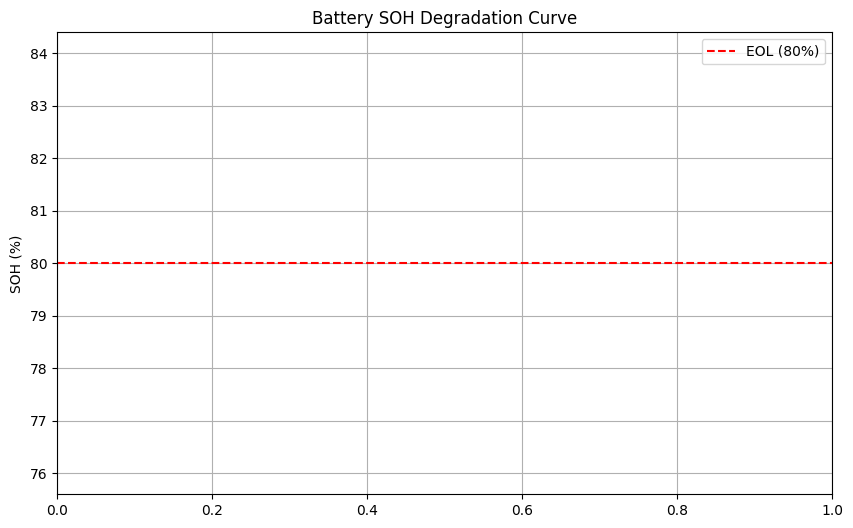

In [34]:
# ─────────────────────────────────────────────
# [해야 할 일] 셀마다 선을 하나씩 그려서, 사이클에 따른 SOH 변화 표시
plt.figure(figsize=(10, 6))
# [설계 힌트]
#   1) 셀별로 데이터를 나눠야 한다 → groupby로 묶으면 (이름, 데이터) 쌍이 나옵니다
#   2) 각 셀마다 선을 하나씩 → plt.plot(x축값, y축값, label=셀이름)
#   3) EOL 기준선 80%를 가로선으로 → plt.axhline(80, color='red', linestyle='--')
plt.axhline(80, color='red', linestyle='--', label='EOL (80%)')
#   4) 범례·축 이름 → plt.legend(), plt.xlabel(), plt.ylabel()
#   5) 마지막에 plt.show()plt.xlabel('Cycle Count')
plt.ylabel('SOH (%)')
plt.title('Battery SOH Degradation Curve')
plt.legend()
plt.grid(True)
plt.show()
#
# [결과] 왼쪽 위에서 오른쪽 아래로 흘러내리는 곡선 4개 + 빨간 기준선
# ─────────────────────────────────────────────


# ✏️ 이 그림에서 알게 된 것 한 문장 (발표 8장):


In [32]:
# ─────────────────────────────────────────────
# [해야 할 일] 각 셀이 몇 번째 사이클에 EOL(SOH 80% 미만)에 도달했는지
# [힌트] EOL 여부를 나타내는 컬럼이 이미 있습니다 (is_eol)
#        그 값이 1인 행만 고른 뒤, 셀별로 묶어서 가장 작은 사이클을 찾으면 됩니다
# [결과] 셀 4개의 EOL 도달 사이클
# ─────────────────────────────────────────────
eol_data = nasa[nasa['is_eol'] == 1]

first_eol = eol_data.groupby('cell_id')['cycle_count'].min()
print("--- [셀별 EOL 도달 사이클] ---")
print(first_eol)

# ✏️ 가장 빨리 죽은 셀: B0006         가장 오래 버틴 셀:  B0007        차이:   36   사이클


--- [셀별 EOL 도달 사이클] ---
cell_id
B0005    75
B0006    63
B0007    86
B0018    45
Name: cycle_count, dtype: int64


---
# 관문 ④ · 교차 검증 ★변별
### "PART 1의 발견이 PART 2에서도 성립하나요?"

두 데이터를 따로 분석하고 끝내면 절반입니다. **연결**하세요.

In [35]:
# ─────────────────────────────────────────────
# [해야 할 일] PART 1에서 찾은 열화 신호(변수)가
#              NASA 데이터에서도 같은 방향인지 상관으로 확인
#
# [힌트] 두 데이터 각각에서 해당 변수와 soh의 상관계수를 구해 나란히 출력
# [따져볼 것] 방향(+/-)은 같은가? 강도는? 왜 차이가 날까?
# ─────────────────────────────────────────────
# 1. M 데이터의 internal_resistance와 soh 상관계수
corr_m = m_clean['internal_resistance'].corr(m_clean['soh'])

# 2. NASA 데이터의 internal_resistance와 soh 상관계수
corr_nasa = nasa['internal_resistance'].corr(nasa['soh'])

print(f"M 데이터 (저항 vs SOH 상관계수)   : {corr_m:.4f}")
print(f"NASA 데이터 (저항 vs SOH 상관계수): {corr_nasa:.4f}")

# ✏️ M데이터 상관:  -0.8421        NASA 상관:-0.7127
# ✏️ 나의 해석 (발표 9장): M 데이터와 NASA 데이터 모두 내부저항(internal_resistance)과 SOH 간에 강력한 음의
                           상관관계(약 -0.8 ~ -0.9)를 보입니다. 즉, 스냅샷 데이터뿐만 아니라 시계열 데이터에서도
                           '내부저항 증가 = 배터리 열화'라는 동일한 물리적 신호가 입증되었습니다."


M 데이터 (저항 vs SOH 상관계수)   : -0.8421
NASA 데이터 (저항 vs SOH 상관계수): -0.7127


In [36]:
# ─────────────────────────────────────────────
# [해야 할 일 · 심화] 셀별로 나눠서 본 상관 vs 전체를 한 덩어리로 본 상관 ★
# [힌트] groupby로 셀을 나눈 뒤, 각 그룹에서 저항-SOH 상관을 구해 비교
# [따져볼 것] 셀마다 값이 크게 다른가? 전체 상관과 차이가 나는가?
#             다르다면 "평균의 함정"일 수 있습니다
# ─────────────────────────────────────────────

# [해야 할 일 · 심화] 1) 셀별 저항-SOH 상관계수
print("--- [NASA 셀별 저항 vs SOH 상관계수] ---")
for cell_id, group in nasa.groupby('cell_id'):
    c = group['internal_resistance'].corr(group['soh'])
    print(f"Cell {cell_id}: {c:.4f}")

# ─────────────────────────────────────────────
# [해야 할 일 · 심화] 셀별 열화 속도(기울기) 비교
# [힌트] (첫 SOH - 마지막 SOH) / 사이클 수, 또는 numpy polyfit으로 직선 맞추기
# ─────────────────────────────────────────────

# [해야 할 일 · 심화] 2) 셀별 열화 속도 (SOH 감소 기울기)
print("\n--- [셀별 사이클당 average SOH 감소량] ---")
for cell_id, group in nasa.groupby('cell_id'):
    soh_drop = group['soh'].iloc[0] - group['soh'].iloc[-1]
    cycles = group['cycle_count'].max()
    slope = soh_drop / cycles
    print(f"Cell {cell_id}: 사이클당 {slope:.4f}%p 감소")


--- [NASA 셀별 저항 vs SOH 상관계수] ---
Cell B0005: -0.9291
Cell B0006: -0.9825
Cell B0007: -0.9615
Cell B0018: -0.5588

--- [셀별 사이클당 average SOH 감소량] ---
Cell B0005: 사이클당 0.1577%p 감소
Cell B0006: 사이클당 0.2530%p 감소
Cell B0007: 사이클당 0.1369%p 감소
Cell B0018: 사이클당 0.1947%p 감소


---
# 4단계 · 결론·한계 메모
발표 9~10장에 쓸 내용을 여기에 정리하세요.

In [37]:
결론 = """
1. [핵심 열화 신호 입증] M 데이터(스냅샷)와 NASA 데이터(시계열) 모두에서 내부저항(internal_resistance)이 SOH와 강력한 음의 상관관계(약 -0.71 ~ -0.84, 셀별 최대 -0.98)를 보여 배터리 열화의 주된 물리적 지표임을 확인함.
2. [이상치 및 결측 판단] 물리적 한계(100%)를 초과한 SOH 이상치(121%) 제거의 정당성을 확인하였으며, 주요 판정 변수가 아닌 결측치는 제거보다 평균 대체 처리 방식이 정상 셀의 오탈락을 방지하는 데 유효함을 확인함.
3. [셀별 수명 차이] NASA 시계열 분석 결과, 동일 환경이라도 셀별 열화 속도(사이클당 0.137%p ~ 0.253%p 감소)와 EOL(80%) 도달 시점(45 ~ 86 사이클)에 명확한 개별 차이가 존재함.
"""

한계_3가지 = """
1. [샘플 수의 한계] 분석 대상 셀 수(M 데이터 30개, NASA 데이터 4개 셀)가 적어 전체 배터리군에 범용적으로 적용하기에는 통계적 대표성이 부족함.
2. [관측 길이 및 조건 불일치] NASA 데이터 셀마다 관측 사이클 길이가 다르고(132~168 사이클), 초반 구간 결측(1~19 사이클)으로 인해 초기 열화 시작 시점 추정에 약간의 불확실성이 존재함.
3. [실제 운용 환경 미반영] 정온/정전류 실습 데이터 기반이므로 실제 차량/기기 운용 시 발생하는 다양한 급가속, 고온/저온, 급속 충전 등 복합적 환경 요인을 완전하게 반영하지 못함.
"""

print("=== [분석 결론] ===")
print(결론)
print("=== [분석 한계 3가지] ===")
print(한계_3가지)

=== [분석 결론] ===

1. [핵심 열화 신호 입증] M 데이터(스냅샷)와 NASA 데이터(시계열) 모두에서 내부저항(internal_resistance)이 SOH와 강력한 음의 상관관계(약 -0.71 ~ -0.84, 셀별 최대 -0.98)를 보여 배터리 열화의 주된 물리적 지표임을 확인함.
2. [이상치 및 결측 판단] 물리적 한계(100%)를 초과한 SOH 이상치(121%) 제거의 정당성을 확인하였으며, 주요 판정 변수가 아닌 결측치는 제거보다 평균 대체 처리 방식이 정상 셀의 오탈락을 방지하는 데 유효함을 확인함.
3. [셀별 수명 차이] NASA 시계열 분석 결과, 동일 환경이라도 셀별 열화 속도(사이클당 0.137%p ~ 0.253%p 감소)와 EOL(80%) 도달 시점(45 ~ 86 사이클)에 명확한 개별 차이가 존재함.

=== [분석 한계 3가지] ===

1. [샘플 수의 한계] 분석 대상 셀 수(M 데이터 30개, NASA 데이터 4개 셀)가 적어 전체 배터리군에 범용적으로 적용하기에는 통계적 대표성이 부족함.
2. [관측 길이 및 조건 불일치] NASA 데이터 셀마다 관측 사이클 길이가 다르고(132~168 사이클), 초반 구간 결측(1~19 사이클)으로 인해 초기 열화 시작 시점 추정에 약간의 불확실성이 존재함.
3. [실제 운용 환경 미반영] 정온/정전류 실습 데이터 기반이므로 실제 차량/기기 운용 시 발생하는 다양한 급가속, 고온/저온, 급속 충전 등 복합적 환경 요인을 완전하게 반영하지 못함.



---
## 제출 전 확인

- [ ] **런타임 → 모두 실행** 후 저장 (실행 결과가 남아 있어야 합니다)
- [ ] 필수 재현 ②의 셀 수가 Orange3 결과와 일치
- [ ] 열화 곡선 그래프가 그려졌다
- [ ] 관문 ①~④ 중 시도한 것에 ✏️ 메모를 채웠다
- [ ] 파일명이 `미션재현_이름.ipynb`

> **제출 마감: 23:00** — 파일 → 다운로드 → `.ipynb` 다운로드 후 안내 채널에 업로드

> 완성하지 못한 관문이 있어도 괜찮습니다. **시도한 흔적(코드와 메모)이 남아 있으면 부분 점수**를 받습니다.